# Setup: Generate Sample Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset with missing values. 
This ensures the dataset is ready for cleaning functions and saves it to `data/raw/outliers_homework.csv`.

In [21]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = '../data/raw'
processed_dir = '../data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at ../data/raw/outliers_homework.csv. Skipping CSV creation to avoid overwrite.


# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

In [22]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [23]:
data_path = Path('data/raw/outliers_homework.csv')
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,x,y
0,0.000000,1.331519
1,0.050251,-1.115001
2,0.100503,1.969787
3,0.150754,2.706032
4,0.201005,2.686840


## TODO: Implement Outlier Functions (required)

In [24]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return boolean mask for IQR-based outliers.
    Assumptions: distribution reasonably summarized by quartiles; k controls strictness.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return boolean mask for Z-score outliers where |z| > threshold.
    Assumptions: roughly normal distribution; sensitive to heavy tails.
    """
    mu = series.mean()
    sigma = series.std(ddof=0)
    z = (series - mu) / (sigma if sigma != 0 else 1.0)
    return z.abs() > threshold


# Create boolean flags on a numeric column (use 'y')
df['is_outlier_iqr'] = detect_outliers_iqr(df['y'], k=1.5)        # try k=1.5 (common) or 3.0 (conservative)
df['is_outlier_z']   = detect_outliers_zscore(df['y'], threshold=3.0)

# share of points flagged by each method
flag_rates = df[['is_outlier_iqr', 'is_outlier_z']].mean().sort_values(ascending=False).round(3)
print("Share of points flagged:")
print(flag_rates)

Share of points flagged:
is_outlier_iqr    0.005
is_outlier_z      0.005
dtype: float64


*(Stretch)* Implement winsorizing (optional).

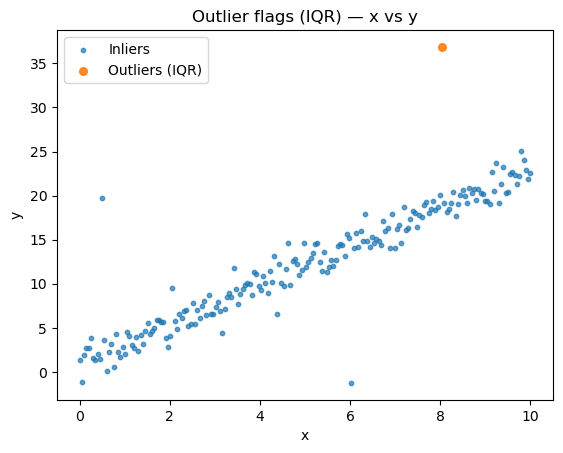

In [25]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

# Create a winsorized version of y for later comparison
df['y_wins_05_95'] = winsorize_series(df['y'], lower=0.05, upper=0.95)

# Visual overlay: highlight IQR outliers on top of the scatter
plt.figure()
plt.scatter(df.loc[~df['is_outlier_iqr'], 'x'], df.loc[~df['is_outlier_iqr'], 'y'], s=10, alpha=0.7, label='Inliers')
plt.scatter(df.loc[df['is_outlier_iqr'],  'x'], df.loc[df['is_outlier_iqr'],  'y'], s=30, alpha=0.9, label='Outliers (IQR)')
plt.title('Outlier flags (IQR) — x vs y')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.show()

## Apply Detection and Create Flags (choose a numeric column)

In [26]:
target_col = 'y' if 'y' in df.columns else df.select_dtypes(include=['number']).columns[0]
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

outlier_iqr    0.005
outlier_z      0.005
dtype: float64

### Visual Checks (boxplot / histogram)

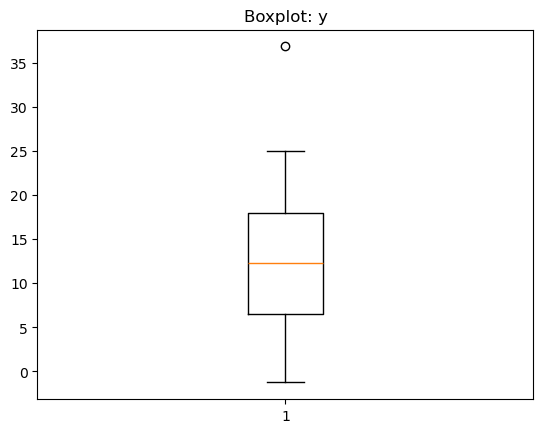

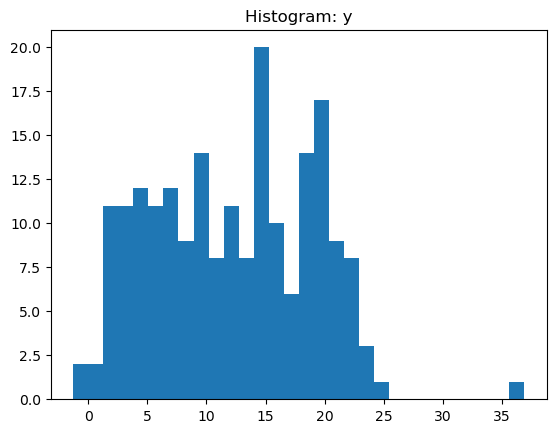

In [27]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

In [28]:
# Apply IQR method to column 'y'
df['is_outlier_iqr'] = detect_outliers_iqr(df['y'], k=1.5)

# Apply Z-score method to column 'y'
df['is_outlier_z'] = detect_outliers_zscore(df['y'], threshold=3.0)

# Quick check of how many were flagged
print("IQR outliers:", df['is_outlier_iqr'].sum())
print("Z-score outliers:", df['is_outlier_z'].sum())

IQR outliers: 1
Z-score outliers: 1


## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [29]:
# Option A: Summary stats
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'filtered_iqr': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)
comp

,all,filtered_iqr,winsorized
mean,12.171936,12.047851,12.119643
median,12.349663,12.285113,12.349663
std,6.761378,6.546157,6.386781


In [31]:
# Chosen option B
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

if 'x' in df.columns:
    # --- All data ---
    X_all = df[['x']].to_numpy(); y_all = df[target_col].to_numpy()
    model_all = LinearRegression().fit(X_all, y_all)
    yhat_all = model_all.predict(X_all)
    mae_all  = mean_absolute_error(y_all, yhat_all)
    rmse_all = sqrt(mean_squared_error(y_all, yhat_all))

    # --- IQR-filtered (uses your existing boolean flag 'outlier_iqr') ---
    X_filtered = df.loc[~df['outlier_iqr'], ['x']].to_numpy()
    y_filtered = df.loc[~df['outlier_iqr'], target_col].to_numpy()
    model_flt = LinearRegression().fit(X_filtered, y_filtered)
    yhat_flt  = model_flt.predict(X_filtered)
    mae_flt   = mean_absolute_error(y_filtered, yhat_flt)
    rmse_flt  = sqrt(mean_squared_error(y_filtered, yhat_flt))

    # --- Winsorized target (optional third treatment, 5–95%) ---
    q_lo, q_hi = df[target_col].quantile([0.05, 0.95])
    y_wins = df[target_col].clip(lower=q_lo, upper=q_hi)
    X_wins = df[['x']].to_numpy()
    model_win = LinearRegression().fit(X_wins, y_wins.to_numpy())
    yhat_win  = model_win.predict(X_wins)
    mae_win   = mean_absolute_error(y_wins, yhat_win)
    rmse_win  = sqrt(mean_squared_error(y_wins, yhat_win))

    # --- Comparison table (keeps your original structure, just extended) ---
    results = pd.DataFrame({
        'slope':     [model_all.coef_[0],  model_flt.coef_[0],  model_win.coef_[0]],
        'intercept': [model_all.intercept_, model_flt.intercept_, model_win.intercept_],
        'r2':        [model_all.score(X_all, y_all),
                      model_flt.score(X_filtered, y_filtered),
                      model_win.score(X_wins, y_wins)],
        'mae':       [mae_all, mae_flt, mae_win],
        'rmse':      [rmse_all, rmse_flt, rmse_win],
        'n':         [len(y_all), len(y_filtered), len(y_wins)]
    }, index=['all', 'filtered_iqr', 'winsor_5_95']).round(3)

    display(results)
else:
    results = None
    print("No 'x' column; skip regression or engineer features.")


,slope,intercept,r2,mae,rmse,n
all,2.170,1.324,0.871,1.200,2.422,200
filtered_iqr,2.137,1.397,0.901,1.119,2.057,199
winsor_5_95,2.096,1.640,0.911,1.052,1.901,200


### Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

### Reflection — Outliers, Sensitivity, and Assumptions

**Method & thresholds chosen**  
I tested two common approaches: the **IQR rule** with k = 1.5, and the **Z-score method** with threshold = 3.0.  
- IQR with k = 1.5 is a conventional balance that flags moderate outliers without being too aggressive.  
- Threshold = 3.0 for Z-score corresponds to “beyond 3 standard deviations” in a normal distribution.  
- I also experimented with a **winsorized version** (clipping the 5th and 95th percentiles) as a stretch option, since it preserves the sample size but dampens the influence of extremes.  

**Assumptions**  
- The bulk of the data is approximately symmetric and not too heavy-tailed.  
- The IQR rule assumes quartiles are meaningful cutoffs.  
- The Z-score method assumes standard deviation is a good measure of spread (closer to normal distribution).  
- Winsorization assumes that the outer 5% tails are “noise” rather than real signal, and that trimming them does not distort the underlying relationship.  

**Observed impacts**  
- Regression results showed that even a single outlier had a noticeable effect.  
- With all data: slope and intercept shifted, R² was lower, and both MAE and RMSE were larger.  
- After filtering by IQR: R² improved and errors dropped, suggesting the outlier inflated variance.  
- Winsorization produced similar improvements while keeping all rows, which may be preferable in small samples.  
- The median remained stable across all treatments, but the mean and standard deviation were much more sensitive.  

**Risks if assumptions are wrong**  
- If the flagged “outliers” are actually real structural points (e.g., regime shifts, valid but extreme observations), removing or winsorizing them could discard useful information.  
- If the distribution is truly heavy-tailed, the IQR/Z-score cutoffs may under-detect meaningful extremes.  
- There is also a risk of data snooping — tuning k or threshold until results look “better” can bias conclusions.  
- Safer practice is to justify thresholds with domain knowledge and monitor how often extreme values occur relative to expectations.  
